In [1]:
from astropy.io import fits
import pandas

# BD 17 from CalSpec

In [2]:
calspec_bd17 = "https://archive.stsci.edu/hlsps/reference-atlases/cdbs/current_calspec/bd_17d4708_stisnic_007.fits"

In [3]:
bd17 = pandas.DataFrame( fits.open(calspec_bd17)[1].data )
bd17 = bd17.set_index(bd17.index.values)
bd17.head()

,WAVELENGTH,FLUX,STATERROR,SYSERROR,FWHM,DATAQUAL,TOTEXP
0,1710.574707,2.556900e-14,2.949600e-15,2.556900e-16,2.742676,1,2913.0
1,1711.946045,1.637600e-14,2.762800e-15,1.637600e-16,2.742676,1,2913.0
2,1713.317383,1.672700e-14,2.740600e-15,1.672700e-16,2.742676,1,2913.0
3,1714.688721,2.120700e-14,2.702000e-15,2.120700e-16,2.742798,1,2913.0
4,1716.060181,2.432100e-14,2.707700e-15,2.432100e-16,2.742798,1,2913.0


In [4]:
flag = bd17["WAVELENGTH"].between(3_000, 20_000).astype(bool).values
lbda_ref = bd17["WAVELENGTH"].astype(float).values[flag]
flux_ref = bd17["FLUX"].astype(float).values[flag]

In [5]:
from slicersim import Simulation

In [8]:
sim = Simulation.from_source(lbda_ref, flux_ref, background="zodi")

<Axes: xlabel='Obsframe wavelength [µm]', ylabel='Signal [ADU]'>

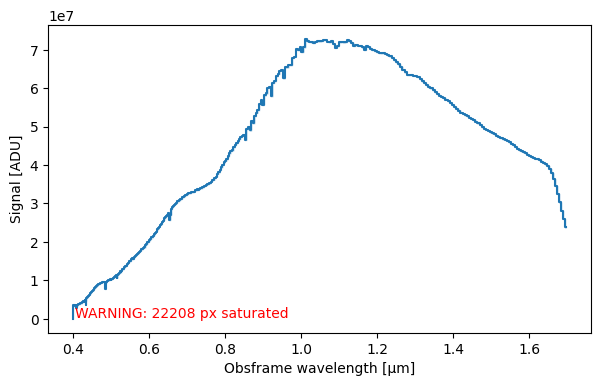

In [9]:
sim.show_spectrum()